# Plant Disease Classifier — Training Notebook (Fixed)

This is a corrected version of the original notebook. Fixes applied:

1. **Validation set was getting training augmentations** (random flips/rotation/color jitter) because a single `ImageFolder` with `train_transforms` was split with `random_split`, and both subsets pointed at the same underlying dataset object/transform. Fixed by building two separate `ImageFolder` datasets (one with train transforms, one with val transforms) and applying the *same* split indices to each via `Subset`.
2. **Hardcoded dataset path** (`data/raw/PlantVillage`) may not match the actual extracted folder structure — added an auto-detection step that searches for the correct class-folder directory after unzipping.
3. **No reproducibility** — added a fixed random seed for Python/NumPy/PyTorch and a `torch.Generator` for the split.
4. **Unused imports** (`classification_report`, `confusion_matrix`) — now actually used in a final evaluation cell with a confusion matrix plot.
5. **No training curves** — added a cell to plot loss/accuracy curves from the tracked history.
6. **No LR scheduler / no best-epoch tracking beyond weights** — added a `ReduceLROnPlateau` scheduler and epoch tracking for the best model.
7. **Device not explicitly reported**, and it's good practice to confirm GPU is in use before a long training run.
8. **Zip extraction had no safety checks** — added a check so re-running the notebook doesn't re-unzip unnecessarily.


In [5]:
from google.colab import files
uploaded = files.upload()

Saving data.zip to data.zip


In [6]:
import os
os.makedirs("models", exist_ok=True)

In [7]:
import os
print(os.listdir("/content"))

['.config', 'models', 'data.zip', 'sample_data']


In [8]:
import zipfile

zip_path = "/content/data.zip"
extract_path = "/content/data"

if not os.path.isdir(extract_path):
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_path)
    print("Extraction complete.")
else:
    print("Data already extracted, skipping.")

Extraction complete.


In [9]:
# Standard Library
import os
import random
from pathlib import Path

# Numerical Computing & Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image Processing
from PIL import Image

# TorchVision
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models

# Data Loading Utilities
from torch.utils.data import DataLoader, random_split, Subset
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

In [10]:
# ================================
# Reproducibility
# ================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [11]:
DATASET_ROOT = Path("/content/data")
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
print(f"Using device: {DEVICE}")
if DEVICE.type == "cpu":
    print("WARNING: No GPU detected. Training will be slow. "
          "Go to Runtime > Change runtime type > GPU in Colab.")

Using device: cuda


In [13]:
# ================================
# Auto-detect the actual class-folder directory
# ================================
# ImageFolder expects DATASET_PATH/<class_name>/<image files>.
# We search under DATASET_ROOT for the first directory that contains
# only subdirectories (i.e. class folders) rather than assuming a fixed
# nested path like "data/raw/PlantVillage".

def find_dataset_dir(root: Path):
    for dirpath, dirnames, filenames in os.walk(root):
        if not dirnames:
            continue
        p = Path(dirpath)
        subdirs = [p / d for d in dirnames]
        if all(any(f.is_file() for f in sd.iterdir()) for sd in subdirs if sd.exists()):
            return p
    raise FileNotFoundError(f"Could not find a class-folder structure under {root}")

DATASET_PATH = find_dataset_dir(DATASET_ROOT)
print(f"Detected dataset path: {DATASET_PATH}")

Detected dataset path: /content/data/data/raw/PlantVillage


In [14]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [15]:
# ================================
# Build two datasets pointing at the same images but with different
# transforms, then apply an identical split to both so the validation
# set never sees training-time augmentation.
# ================================
train_dataset_full = datasets.ImageFolder(root=DATASET_PATH, transform=train_transforms)
val_dataset_full = datasets.ImageFolder(root=DATASET_PATH, transform=val_transforms)

class_names = train_dataset_full.classes
print(f"Total Classes : {len(class_names)}")
print(class_names)

assert train_dataset_full.samples == val_dataset_full.samples, \
    "Train/val ImageFolder orderings differ — cannot safely share split indices."

n_total = len(train_dataset_full)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

generator = torch.Generator().manual_seed(SEED)
train_indices, val_indices = random_split(
    range(n_total), [n_train, n_val], generator=generator
)

train_dataset = Subset(train_dataset_full, train_indices.indices)
val_dataset = Subset(val_dataset_full, val_indices.indices)

print(f"Training Images : {len(train_dataset)}")
print(f"Validation Images : {len(val_dataset)}")

Total Classes : 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Training Images : 16510
Validation Images : 4128


In [16]:
# ================================
# Create DataLoaders
# ================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Training Batches : {len(train_loader)}")
print(f"Validation Batches : {len(val_loader)}")

Training Batches : 516
Validation Batches : 129


In [17]:
# ================================
# Check One Batch
# ================================
images, labels = next(iter(train_loader))
print("Image Batch Shape :", images.shape)
print("Label Shape :", labels.shape)

Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Shape : torch.Size([32])


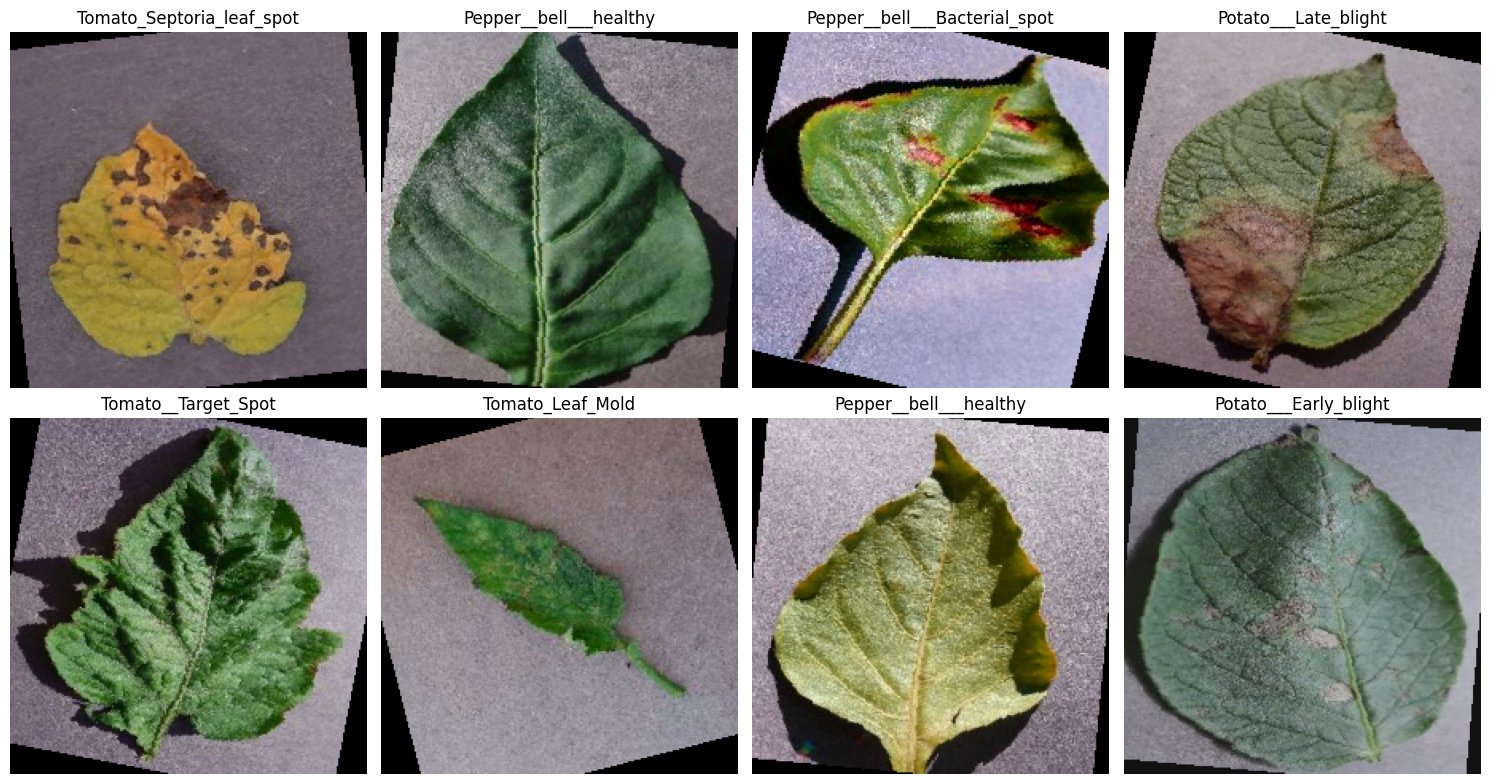

In [18]:
# ================================
# Display Sample Images
# ================================
def imshow(img):
    img = img.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis("off")

plt.figure(figsize=(15, 8))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    imshow(images[i])
    plt.title(class_names[labels[i]])
plt.tight_layout()
plt.show()

In [19]:
# ================================
# Load EfficientNet-B0
# ================================
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 182MB/s]


In [20]:
# Replace final layer
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(
    in_features,
    len(class_names)
)

In [21]:
model = model.to(DEVICE)
print(model)

# ================================
# Loss, Optimizer & Scheduler
# ================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [22]:
best_val_acc = 0.0
best_epoch = -1

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [23]:
for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print("-" * 50)

    # ================================
    # TRAINING
    # ================================
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc="Train"):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ================================
    # VALIDATION
    # ================================
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Val"):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100 * correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step(val_acc)

    # ================================
    # PRINT RESULTS
    # ================================
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.2f}%")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")

    # ================================
    # SAVE BEST MODEL
    # ================================
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "image_size": IMAGE_SIZE,
            "num_classes": len(class_names)
        }, "models/best_model.pth")
        print("Best model saved!")

print("\nTraining Completed!")
print(f"\nBest Validation Accuracy : {best_val_acc:.2f}% (epoch {best_epoch})")


Epoch [1/10]
--------------------------------------------------


Val: 100%|██████████| 129/129 [00:12<00:00, 10.19it/s]


Train Loss : 0.3172
Train Acc  : 90.12%
Val Loss   : 0.0654
Val Acc    : 97.99%
Best model saved!

Epoch [2/10]
--------------------------------------------------


Val: 100%|██████████| 129/129 [00:12<00:00, 10.29it/s]


Train Loss : 0.1237
Train Acc  : 96.10%
Val Loss   : 0.0630
Val Acc    : 98.13%
Best model saved!

Epoch [3/10]
--------------------------------------------------


...

Train Loss : 0.0608
Train Acc  : 98.03%
Val Loss   : 0.0632
Val Acc    : 97.94%

Epoch [9/10]
--------------------------------------------------


Val: 100%|██████████| 129/129 [00:12<00:00, 10.29it/s]


Train Loss : 0.0568
Train Acc  : 98.03%
Val Loss   : 0.0243
Val Acc    : 99.13%
Best model saved!

Epoch [10/10]
--------------------------------------------------


Val: 100%|██████████| 129/129 [00:12<00:00, 10.15it/s]

Train Loss : 0.0439
Train Acc  : 98.49%
Val Loss   : 0.0394
Val Acc    : 98.84%

Training Completed!

Best Validation Accuracy : 99.13% (epoch 9)


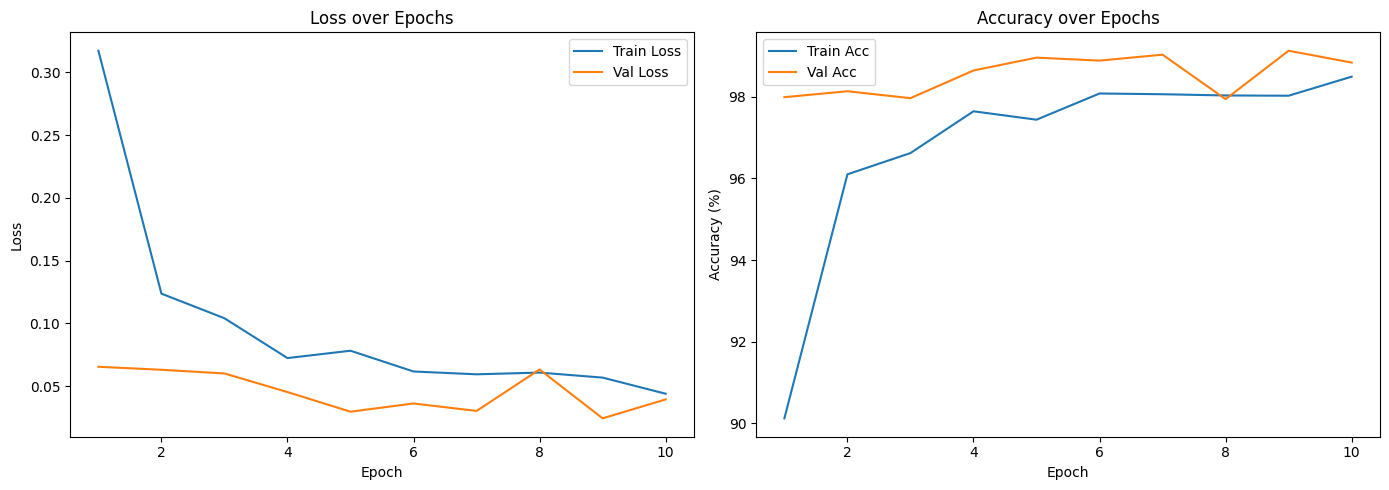

In [24]:
# ================================
# Plot Training Curves
# ================================
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label="Train Acc")
plt.plot(epochs_range, val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

Evaluating best model: 100%|██████████| 129/129 [00:12<00:00, 10.10it/s]


                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      1.00      0.99       188
                     Pepper__bell___healthy       1.00      0.99      1.00       307
                      Potato___Early_blight       1.00      0.98      0.99       214
                       Potato___Late_blight       1.00      1.00      1.00       211
                           Potato___healthy       0.94      1.00      0.97        30
                      Tomato_Bacterial_spot       1.00      0.97      0.98       448
                        Tomato_Early_blight       0.98      0.99      0.99       196
                         Tomato_Late_blight       0.99      0.99      0.99       361
                           Tomato_Leaf_Mold       0.99      1.00      0.99       191
                  Tomato_Septoria_leaf_spot       0.99      1.00      1.00       349
Tomato_Spider_mites_Two_spotted_spider_mite       1.00      0.99

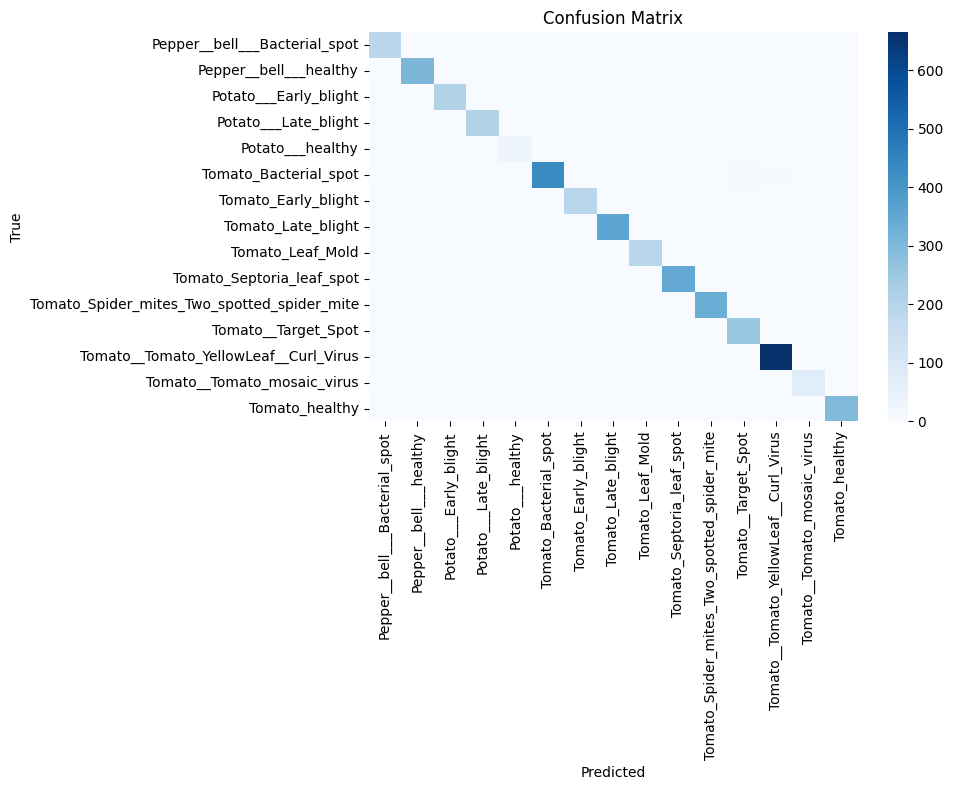

In [25]:
# ================================
# Final Evaluation: Classification Report & Confusion Matrix
# (loads the best saved checkpoint, not just the last epoch's weights)
# ================================
checkpoint = torch.load("models/best_model.pth", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating best model"):
        images = images.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
from google.colab import files

files.download("models/best_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>